# LegalBERT Embedding Clustering Analysis

This notebook loads the pre-computed LegalBERT embeddings (from `lrec-tcs-lbert-clf-w-save.ipynb`) and the full text dataset to perform clustering analysis and investigate the cluster composition.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 59.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import os
import re
import logging
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


# Setup basic logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
if not logger.handlers:
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

2025-10-29 09:04:13.982087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761728654.256364      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761728654.328546      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 1. Load Data and Embeddings

**Note:** Please ensure `sentencePair.txt`, `sentencePair_neg.txt`, and the `artifacts` directory (containing `combined_embeddings.npy` and `combined_ids.csv`) are in the same directory as this notebook.

In [3]:
class Config:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    EMB_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/lbert_finetuned_embeddings.npy"
    IDS_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/lbert_finetuned_ids.csv"
    # EMB_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_embeddings.npy"
    # IDS_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_ids.csv"

def parse_lrec_line(line: str):
    """
    Parses a single line from the .txt file.
    MUST be identical to the function in the LBERT notebook.
    """
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        # Use 'sentpair_id' to match the LBERT notebook's internal name
        sentpair_id = int(parts[0]) 
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: Config):
    """
    Loads, cleans, splits, and concatenates data in the *exact* same
    order as the LBERT notebook's `load_and_split_data` followed by
    the creation of the 'combined' PairDataset.
    This ensures 1:1 row alignment with 'combined_embeddings.npy'.
    """
    logging.info("Loading full dataset with LBERT-compatible split/concat logic...")
    rows = []
    
    # --- 1. Load from both files (identical to load_and_split_data) ---
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(fp):
            logging.error(f"Data file not found at '{fp}'. Please add it.")
            return None
        with open(fp, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line):
                    # --- Use 'sentpair_id' consistently ---
                    if 'id' in parsed: # If parse_lrec_line uses 'id'
                        parsed['sentpair_id'] = parsed.pop('id')
                    rows.append(parsed)
                    
    df = pd.DataFrame(rows)
    
    # --- 2. Clean data (identical to load_and_split_data) ---
    LABEL_MAP = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2} # Local definition
    df["label_id"] = df["label"].map(LABEL_MAP)
    # --- Use 'sentpair_id' for dropna subset ---
    df = df.dropna(subset=["sentpair_id", "sent1", "sent2", "label_id"])
    
    # --- 3. Perform the Train/Test Split (identical to load_and_split_data) ---
    # config variables
    RANDOM_STATE = 42
    TEST_SET_SIZE = 0.2
    
    train_df, test_df = train_test_split(df, test_size=TEST_SET_SIZE,
                                         random_state=RANDOM_STATE,
                                         stratify=df["label_id"])
    
    # Reset index *after* split, just like before
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    
    # --- 4. Concatenate Train and Test (identical to 'combined' PairDataset creation) ---
    df_combined_ordered = pd.concat([train_df, test_df]).reset_index(drop=True)
    
    # Ensure label_id is integer type
    df_combined_ordered['label_id'] = df_combined_ordered['label_id'].astype(int)
    
    logging.info(f"Full dataset loaded and processed like LBERT notebook. Total samples: {len(df_combined_ordered)}")
    
    # This df is now row-aligned with the embeddings
    return df_combined_ordered

# --- Load all components ---
cfg = Config()
df_aligned = load_full_data(cfg) 

if df_aligned is not None:
    embeddings = np.load(cfg.EMB_PATH)
    ids_df = pd.read_csv(cfg.IDS_PATH) # Load for verification
    
    logger.info(f"Loaded DataFrame shape: {df_aligned.shape}")
    logger.info(f"Loaded embeddings shape: {embeddings.shape}")
    logger.info(f"Loaded IDs shape: {ids_df.shape}")
    
    # --- Alignment Check ---
    if len(df_aligned) == len(embeddings) and len(df_aligned) == len(ids_df):
        logger.info("SUCCESS: DataFrame, embeddings, and IDs have matching lengths.")
        # Final check: compare the IDs column-wise
        mismatches = (df_aligned['sentpair_id'] != ids_df['id']).sum()
        if mismatches == 0:
            logger.info("✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.")
        else:
            logger.error(f"--- CRITICAL ERROR ---")
            logger.error(f"ID mismatch detected: {mismatches} rows have different IDs.")
            logger.error("Even though lengths match, the row order is incorrect.")
            logger.error("Check data parsing/cleaning/splitting logic VERY carefully.")
            df_aligned = None # Stop execution
    else:
        logger.error("--- CRITICAL ERROR ---")
        logger.error("Shape mismatch between loaded data and embeddings.")
        logger.error(f"DataFrame rows: {len(df_aligned)}")
        logger.error(f"Embedding rows: {len(embeddings)}")
        logger.error(f"ID CSV rows: {len(ids_df)}")
        logger.error("This means the data loading logic is out of sync with the embedding generation notebook.")
        df_aligned = None # Stop subsequent cells
else:
    logger.error("Could not load data. Halting notebook execution.")


2025-10-29 09:04:43,489 - INFO - Loaded DataFrame shape: (40506, 5)
2025-10-29 09:04:43,489 - INFO - Loaded embeddings shape: (40506, 768)
2025-10-29 09:04:43,490 - INFO - Loaded IDs shape: (40506, 1)
2025-10-29 09:04:43,492 - INFO - SUCCESS: DataFrame, embeddings, and IDs have matching lengths.
2025-10-29 09:04:43,494 - INFO - ✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.


## 2. Elbow Method for Optimal K (Knee Plot)

Calculate the Sum of Squared Distances (Inertia) for different `k` values. The 'elbow' or 'knee' suggests a good trade-off.

2025-10-29 09:04:43,530 - INFO - Calculating SSE for k in range(1, 11)...


  0%|          | 0/10 [00:00<?, ?it/s]

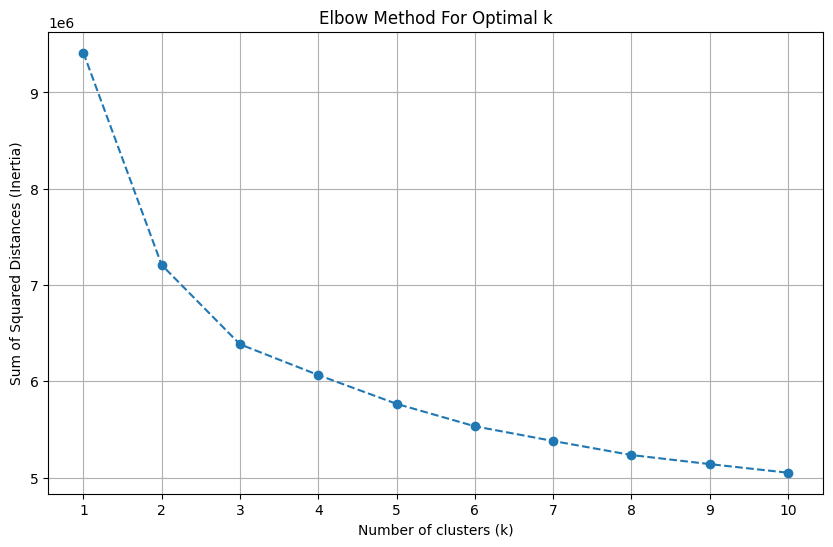

2025-10-29 09:06:37,633 - INFO - Examine the plot. The 'elbow' point indicates a potential optimal k.
2025-10-29 09:06:37,634 - INFO - Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).


In [4]:
if embeddings is not None:
    sse = {}
    k_range = range(1, 11) # Test k from 1 to 10
    logger.info(f"Calculating SSE for k in {k_range}...")

    for k_val in tqdm(k_range):
        kmeans_elbow = KMeans(n_clusters=k_val, random_state=42, n_init=10)
        kmeans_elbow.fit(embeddings)
        sse[k_val] = kmeans_elbow.inertia_ # SSE

    # Plotting the Elbow Curve
    plt.figure(figsize=(10, 6))
    plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Sum of Squared Distances (Inertia)")
    plt.title("Elbow Method For Optimal k")
    plt.xticks(list(sse.keys()))
    plt.grid(True)
    plt.show()

    logger.info("Examine the plot. The 'elbow' point indicates a potential optimal k.")
    logger.info("Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).")
else:
     logger.error("Cannot run Elbow method because embeddings are not loaded.")

## 3. K-Means Clustering

Choose `n_clusters` based on the elbow plot or your hypothesis.

In [5]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 2 # Defaulting to 2, ADJUST AS NEEDED based on Elbow plot
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:06:37,683 - INFO - Running K-Means with n_clusters=2...
2025-10-29 09:07:34,699 - INFO - For n_clusters = 2, the average silhouette_score is : 0.2158


## 4. Analysis: Cluster Composition

2025-10-29 09:07:34,741 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0      1
label                
ATTACK    9007    753
NO_REL    1897  18103
SUPPORT  10259    487


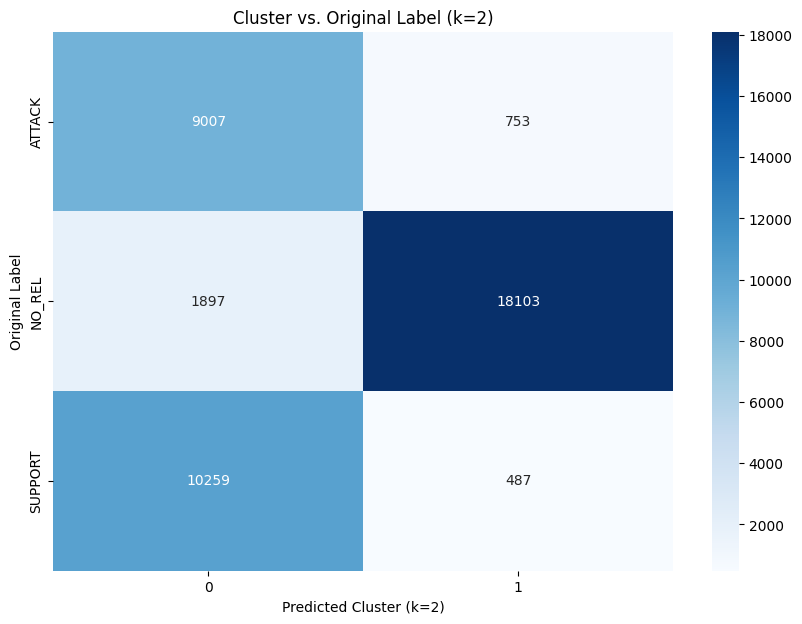

In [6]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")


# For n = 2, Precision = 19266/21163 = 0.91 (Argumentative vs Non Argumentative)
# Recall = 19266/20506 = 0.94
# F1 = 0.9247

## 5. Analysis: Sample Inspection

checking few points from each cluster

In [7]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:07:35,031 - INFO - Found 2 unique cluster labels: [0, 1]
2025-10-29 09:07:35,032 - INFO - Sample Points from Cluster 0
2025-10-29 09:07:35,045 - INFO - Sample Points from Cluster 1


\n==================================================
                                                                                                                                                                                                         sent1  \
16554       It has also not been averred that the memorandum/articles of the plaintiff company give 7 any right to Shri A.K. Shukla to sign , verify and institute a suit on behalf of the plaintiff company .   
12991   Reverting to the facts of this case , we are of the considered view that the impugned judgment of the High Court in declining to exercise its inherent power has led to grave miscarriage of justice .   
22427  The learned counsel for the respondents vehemently contended that the promotional opportunity under the Rules is only a mirage by reason of the qualifications prescribed thereto which are impossib...   
10101  There can not , in our opinion , be any doubt about the correctness of the legal position that trust

## 6. Visualization with UMAP

visualizing the clusters to see the separation.

2025-10-29 09:07:35,099 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2025-10-29 09:08:44,992 - INFO - Plotting by K-Means Cluster (k=2)...


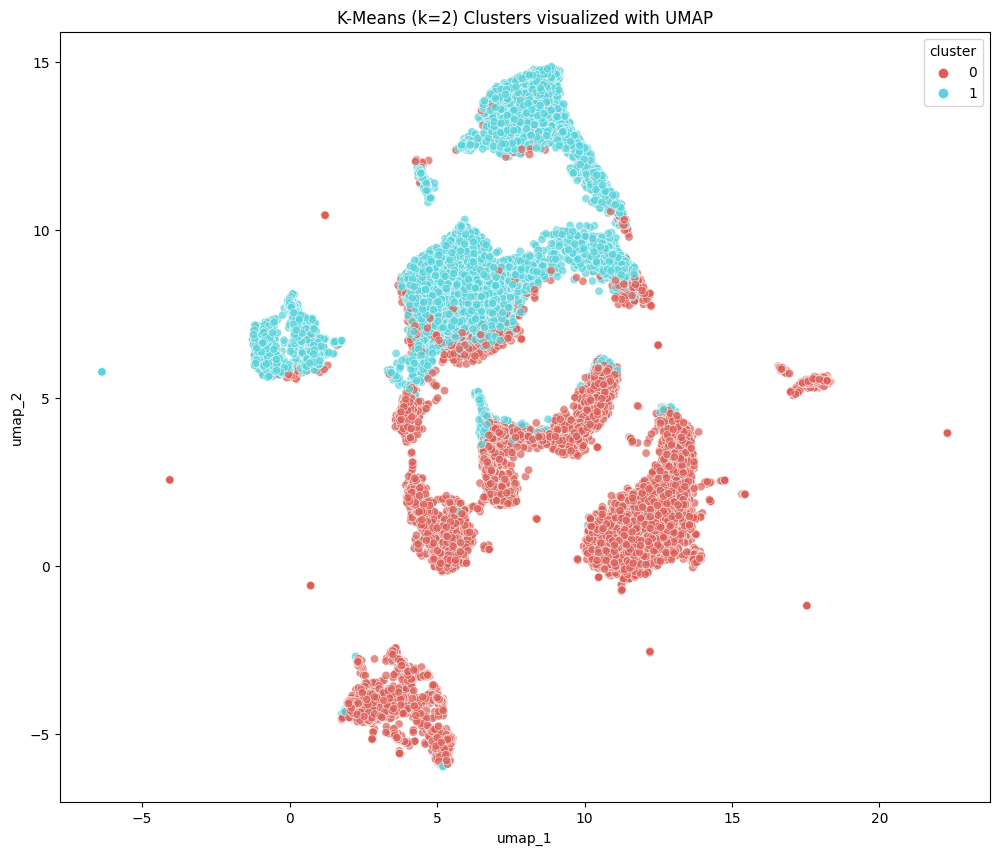

2025-10-29 09:08:46,423 - INFO - Plotting by Original Label...


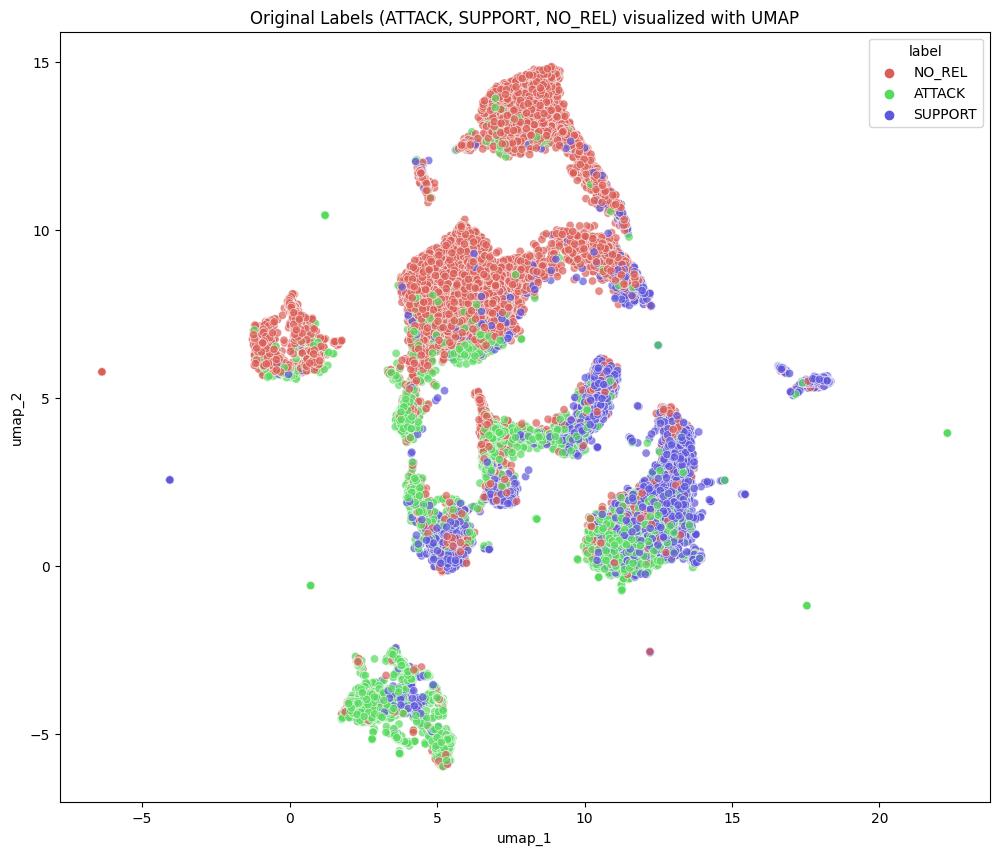

2025-10-29 09:08:47,906 - INFO - Plotting UMAP with Color=Cluster (k=2), Shape=Original Label...


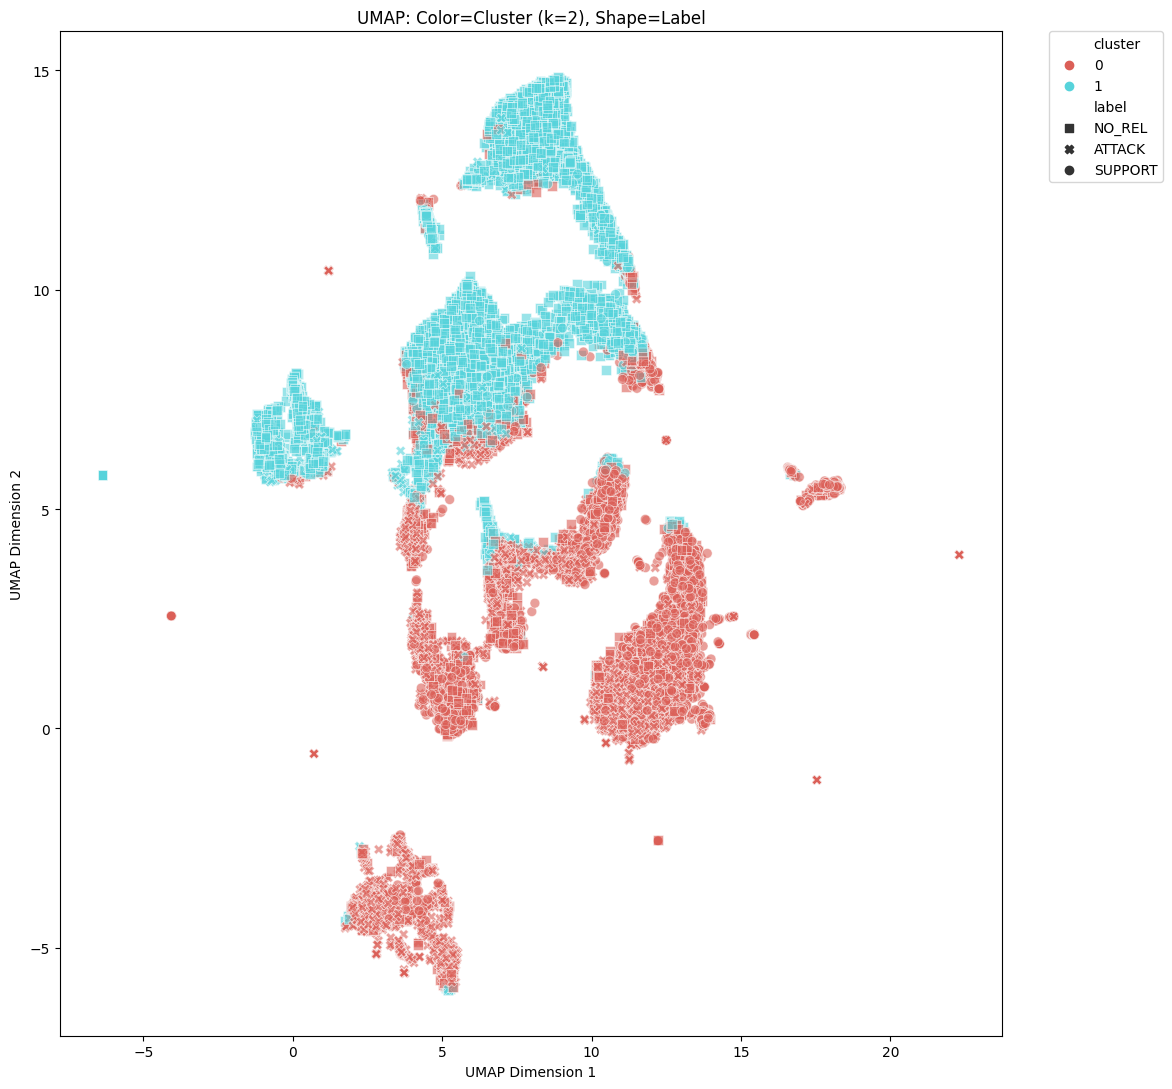

In [8]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for 3 Clusters

In [9]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 3
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:08:49,291 - INFO - Running K-Means with n_clusters=3...
2025-10-29 09:09:52,296 - INFO - For n_clusters = 3, the average silhouette_score is : 0.2023


2025-10-29 09:09:52,382 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster     0      1     2
label                     
ATTACK   1203    578  7979
NO_REL   1483  17561   956
SUPPORT  9442    295  1009


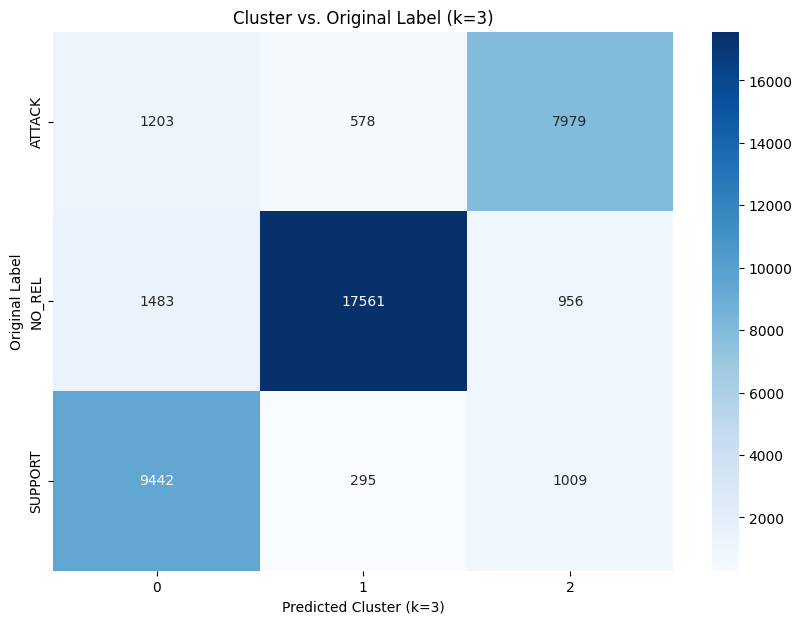

In [10]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")


# For n = 3, Precision = 19266/21163 = 0.91
# Recall = 19266/20506 = 0.94
# F1 = 0.9247

In [11]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:09:52,726 - INFO - Found 3 unique cluster labels: [0, 1, 2]
2025-10-29 09:09:52,728 - INFO - Sample Points from Cluster 0
2025-10-29 09:09:52,740 - INFO - Sample Points from Cluster 1
2025-10-29 09:09:52,750 - INFO - Sample Points from Cluster 2


\n==================================================
                                                                                                                                                                                                         sent1  \
19811  Mr. Ray urged that in the instant case there was no prejudice caused to the Respondent No.1 either by the non-service of the report of the Enquiry Officer or by the non-issuance of a second show-c...   
32890  But learned counsel appearing on his behalf urges that the presumption under section 4(1 ) can be raised only if the prosecution establishes in the first instance that the amount was paid otherwis...   
7136           Where the Constitution thought it fit to do so , it has itself provided for elections by secret ballot , e.g. , in case of election of the President of India and the Vice-President of India .   
4316   In fact , the High Court , while deciding on this issue had observed that the pleadings of the parti

2025-10-29 09:09:52,827 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2025-10-29 09:10:38,658 - INFO - Plotting by K-Means Cluster (k=3)...


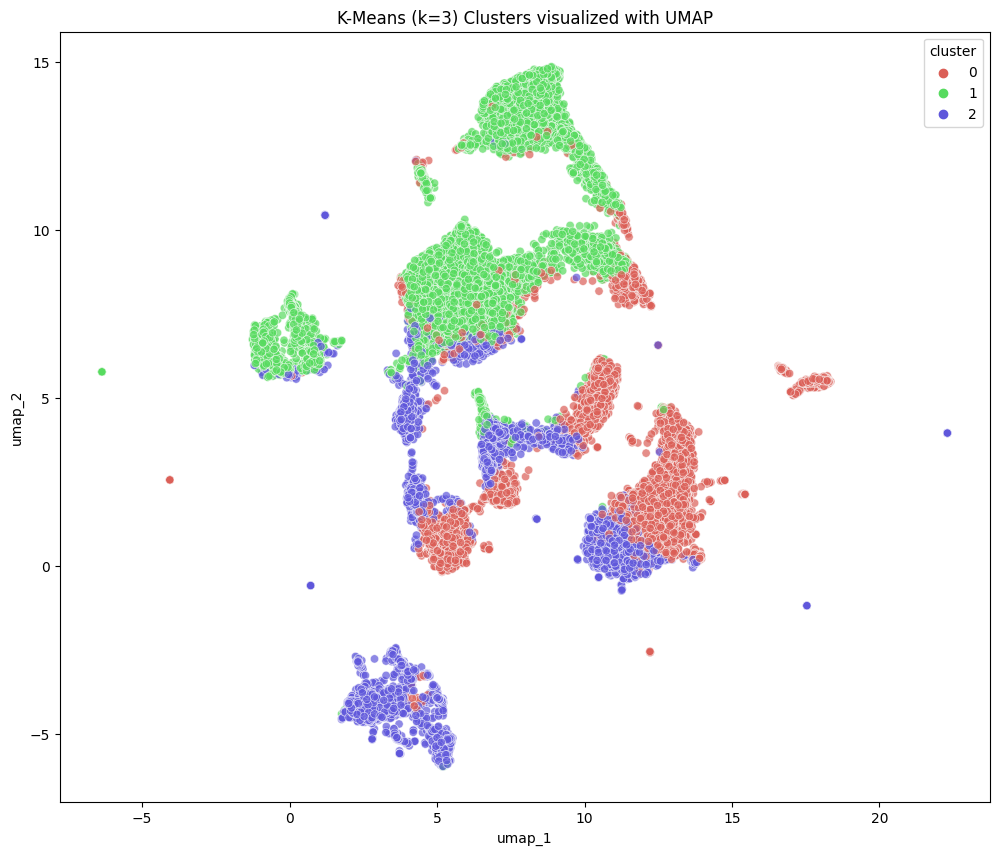

2025-10-29 09:10:40,142 - INFO - Plotting by Original Label...


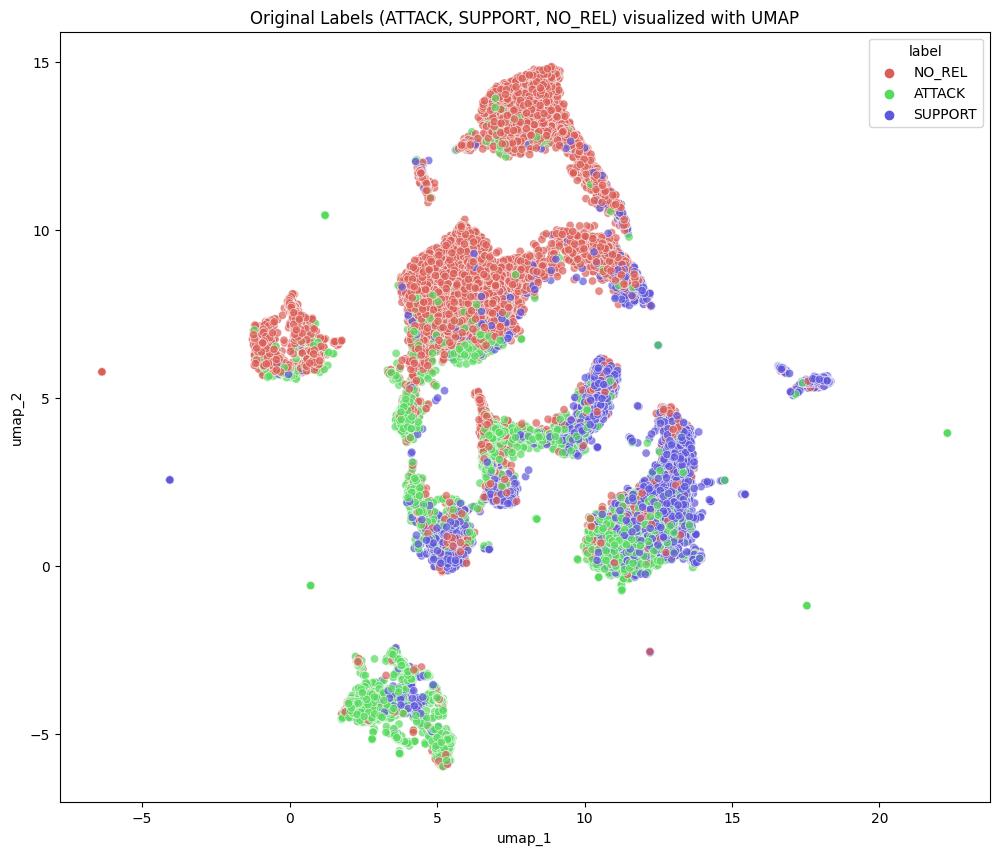

2025-10-29 09:10:41,614 - INFO - Plotting UMAP with Color=Cluster (k=3), Shape=Original Label...


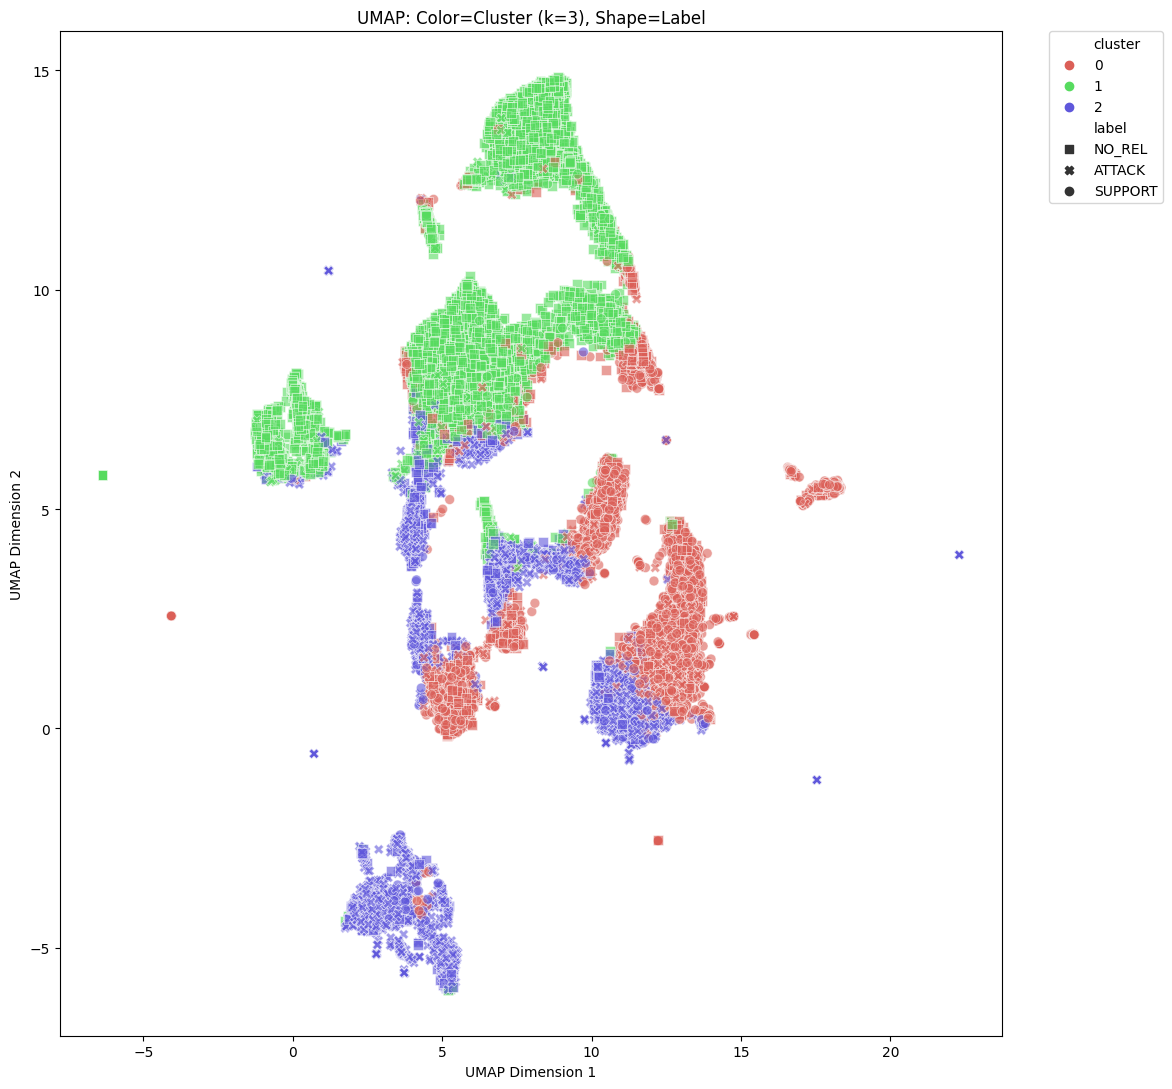

In [12]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for Optimal Clusters

In [13]:
if df_aligned is not None and embeddings is not None:
    
    n_clusters = 4
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:10:43,142 - INFO - Running K-Means with n_clusters=4...
2025-10-29 09:11:46,412 - INFO - For n_clusters = 4, the average silhouette_score is : 0.1783


2025-10-29 09:11:46,547 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0     1     2     3
label                           
ATTACK     569   242  3831  5118
NO_REL   17218  1487   577   718
SUPPORT    249  6563  3758   176


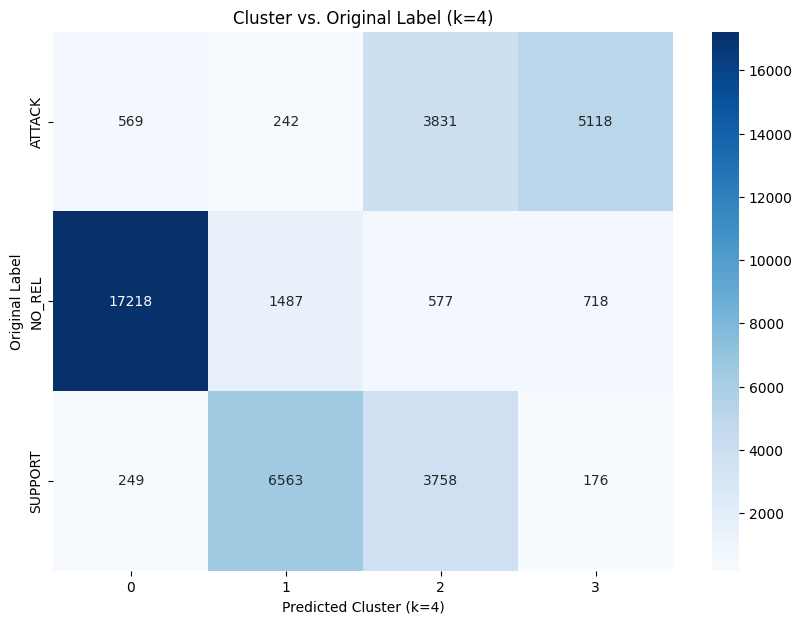

In [14]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")


# For n = 2, Precision = 19266/21163 = 0.91 (Argumentative vs Non Argumentative)
# Recall = 19266/20506 = 0.94
# F1 = 0.9247

In [15]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:11:46,923 - INFO - Found 4 unique cluster labels: [0, 1, 2, 3]
2025-10-29 09:11:46,924 - INFO - Sample Points from Cluster 0
2025-10-29 09:11:46,937 - INFO - Sample Points from Cluster 1
2025-10-29 09:11:46,945 - INFO - Sample Points from Cluster 2
2025-10-29 09:11:46,952 - INFO - Sample Points from Cluster 3


\n==================================================
                                                                                                                                                                                                         sent1  \
31947                                       The controversy , therefore , narrows down to the short point as to what exactly has been adopted as the basis of the levy of sale tax by the Madras Legislature .   
28303                                                    No act done , or proceeding taken under this Act shall be questioned merely on the ground- ( a ) ....................................................   
18862  No suit shall be maintained against any person claiming title under a purchase certified by the Court in such manner as may be prescribed on the ground that the purchase was made on behalf of the ...   
11526                                                                                                      

2025-10-29 09:11:47,063 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2025-10-29 09:12:34,095 - INFO - Plotting by K-Means Cluster (k=4)...


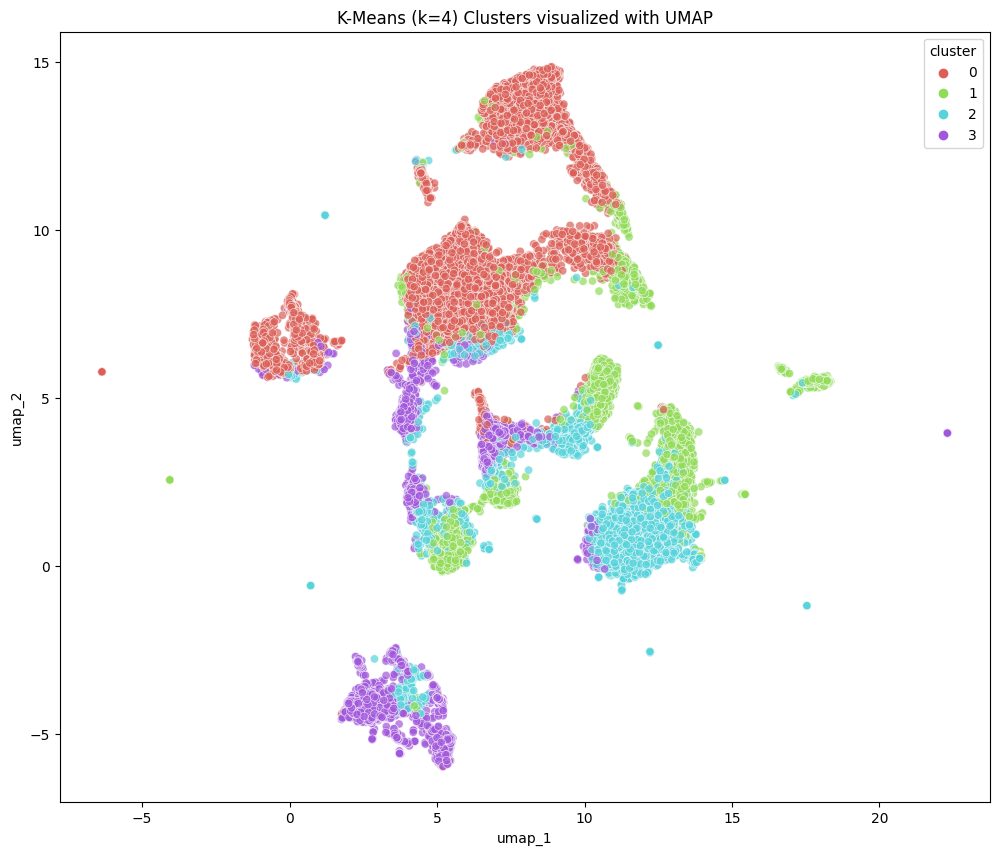

2025-10-29 09:12:35,590 - INFO - Plotting by Original Label...


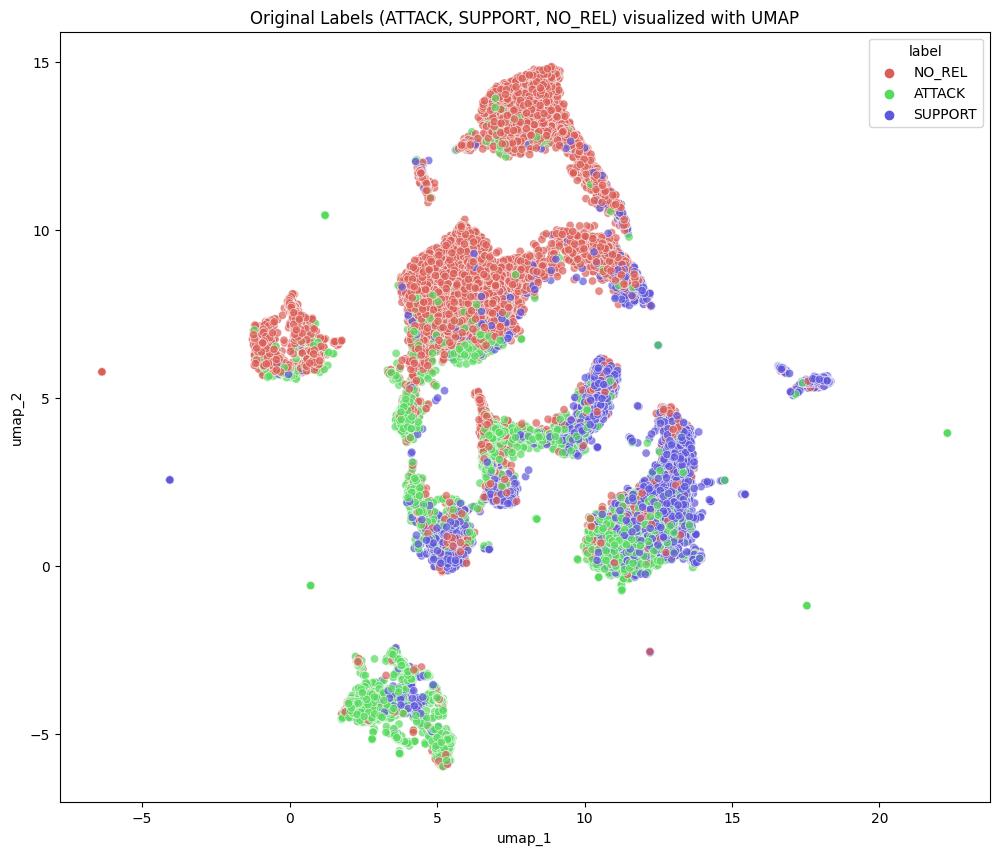

2025-10-29 09:12:37,055 - INFO - Plotting UMAP with Color=Cluster (k=4), Shape=Original Label...


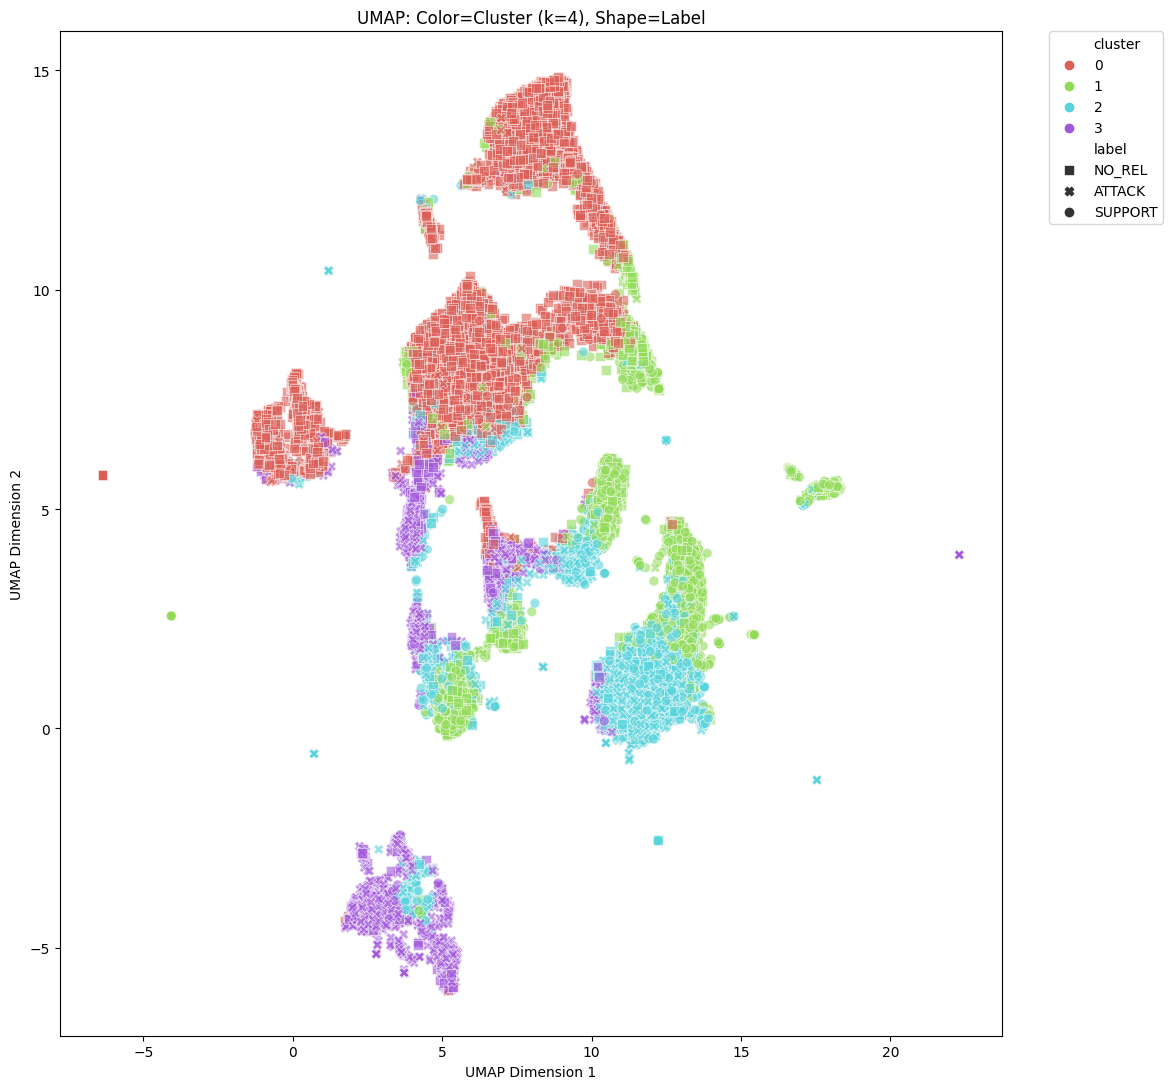

In [16]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")